Also explore https://towardsdatascience.com/exploratory-data-analysis-on-heart-disease-uci-data-set-ae129e47b323 

* Main results for tomorrow:

5-fold cross validation accuracy on CL and HG for all models:
1. LR
2. SVM
3. DT
4. RF
5. MLP
6. XGB

What are the precision and recall for 5 fold-cross validation in test_size = 0.2, 0.3 and 0.4

Forward and Reverse experiment with CL and HG datasets:

Per round how many we could label (100 models agreed), distribution of two classes 

Forward expr, for how many samples in orig HG and derived HG the labels match? What is the percentage? Is it for a specific class? 

Reverse expr, for how many samples in orig CL and derived CL the labels match? What is the percentage? Is any one class dominating?

Repeat with various test_size: 0.2 (default), 0.3 and 0.4 (What else here?)

Repeate with various agreement rates: 100 (model), 90, 80, 75, 70? 

For easy repeatability, make the code more modular. 

In [ ]:
# !pip install umap-learn
# !pip install umap-plot
# !pip install -U ydata-profiling

In [ ]:
# import sys
# !{sys.executable} -m pip install -U ydata-profiling[notebook]
# !jupyter nbextension enable --py widgetsnbextension

# import sys
# !{sys.executable} -m pip install -U pandas-profiling

In [29]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# import umap.plot

In [5]:
# !pip freeze | grep Pyarrow

In [6]:
%matplotlib inline

In [7]:
base_base_base_base_base_base_df = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/Dataset/Heart_Disease_UCI_1988/processed_cleveland.csv")
tobe_labelled_df = pd.read_csv("/Users/bhavesh/Documents/AU/PhD/model_agreement_expr/Dataset/Heart_Disease_UCI_1988/preprocessed_hungary.csv")

In [8]:
base_df = base_df.set_index('Unnamed: 0')
base_df = base_df.rename_axis(index=None)

In [27]:
base_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,diagnosis
Cleveland_0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,0
Cleveland_1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1
Cleveland_2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1
Cleveland_3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,0
Cleveland_4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
Cleveland_298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,1
Cleveland_299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,1
Cleveland_300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,1
Cleveland_301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,1


In [9]:
from ydata_profiling import ProfileReport

In [13]:
# df = pd.DataFrame(np.random.rand(100, 5), columns=["a", "b", "c", "d", "e"])

profile = ProfileReport(base_df, title="Profiling Report")

In [ ]:
# profile.to_notebook_iframe()
# profile.to_widgets()

profile.to_file("cl_report.html")

In [23]:
base_df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'diagnosis'],
      dtype='object')

In [26]:
# base_df = base_df[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
#        'exang', 'oldpeak', 'diagnosis']]

# print(base_df.isnull().sum().sort_values(ascending=False))
print(base_df.isna().sum().sort_values(ascending=False))

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak      0
diagnosis    0
dtype: int64


In [33]:
# base_df.diagnosis.describe()

base_df['diagnosis'] = base_df['diagnosis'].astype(int)

In [40]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, Cleveland_0 to Cleveland_302
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    float64
 1   sex        303 non-null    float64
 2   cp         303 non-null    float64
 3   trestbps   303 non-null    float64
 4   chol       303 non-null    float64
 5   fbs        303 non-null    float64
 6   restecg    303 non-null    float64
 7   thalch     303 non-null    float64
 8   exang      303 non-null    float64
 9   oldpeak    303 non-null    float64
 10  diagnosis  303 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 36.5+ KB


In [45]:
# base_df.diagnosis
# base_df.diagnosis.map({"No HD":0, "HD_1":1, "HD_2":2, "HD_3":3, "HD_4":4})

Cleveland_0     NaN
Cleveland_1     NaN
Cleveland_2     NaN
Cleveland_3     NaN
Cleveland_4     NaN
                 ..
Cleveland_298   NaN
Cleveland_299   NaN
Cleveland_300   NaN
Cleveland_301   NaN
Cleveland_302   NaN
Name: diagnosis, Length: 303, dtype: float64

In [18]:
base_df.loc[base_df["diagnosis"] == 2, "diagnosis"] = 1
base_df.loc[base_df["diagnosis"] == 3, "diagnosis"] = 1
base_df.loc[base_df["diagnosis"] == 4, "diagnosis"] = 1

How to find the number of neighbours for UMAP?


(303, 2)


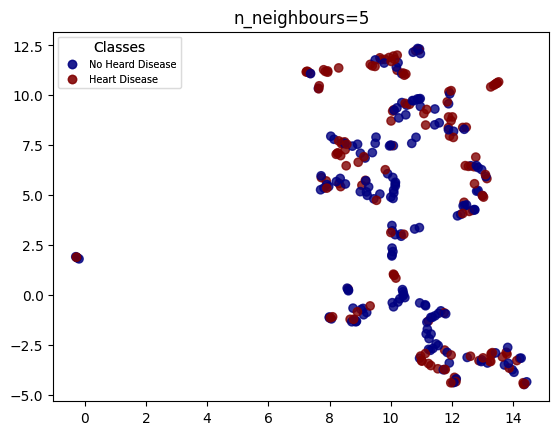

In [26]:
# for plotting one UMAP


n_neighbours = 5
reducer = umap.UMAP(n_neighbors=n_neighbours)
embedding = reducer.fit_transform(base_df)
print(embedding.shape)

# plt.scatter(embedding[:, 0], embedding[:, 1], c=base_df.diagnosis, s=0.5);
fig, ax = plt.subplots()
scatter =  ax.scatter(embedding[:, 0], embedding[:,1], alpha=0.8, c=base_df.diagnosis, cmap='jet')
# legend1 = ax.legend(handles=scatter.legend_elements(alpha=0.8)[0], labels=["No_HD", "HD_1", "HD_2", "HD_3", "HD_4"],
#                     loc="best", title="Classes", draggable=True, fontsize=7, framealpha=0.5)
legend1 = ax.legend(handles=scatter.legend_elements(alpha=0.8)[0], labels=["No Heard Disease", "Heart Disease"],
                    loc="best", title="Classes", draggable=True, fontsize=7, framealpha=0.5)
ax.add_artist(legend1)
plt.title("n_neighbours="+str(n_neighbours))
plt.show()

In [ ]:
# for plotting UMAP

n_neighbours = 15
reducer = umap.UMAP(n_neighbors=n_neighbours)
embedding = reducer.fit_transform(stmfr_true_data.drop('label', axis=1))
print(embedding.shape)

fig, ax = plt.subplots()
scatter =  ax.scatter(embedding[:, 0], embedding[:,1], alpha=0.8, c=stmfr_true_data.label.map({"hESC":0, "hMSC":1, "hUSC":2, "hOPSC":3, "iPSC":4}), cmap='jet')
legend1 = ax.legend(handles=scatter.legend_elements(alpha=0.8)[0], labels=["hESC", "hMSC", "hUSC", "hOPSC", "iPSC"],
                    loc="best", title="Classes", draggable=True, fontsize=7, framealpha=0.5)
ax.add_artist(legend1)
plt.title("n_neighbours="+str(n_neighbours))
plt.show()